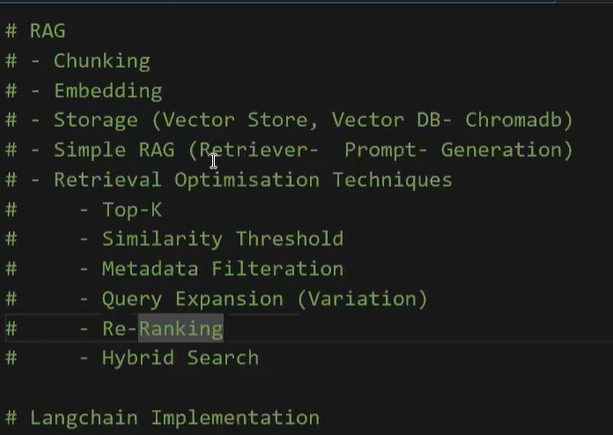

# Re-Ranking

In [1]:
# Top-k -> 50
# Threshold -> .5
# Retrieval- 20 docs
# Re-rank these 20 docs and get top-3 or top-5

In [2]:
# Query
# What is the password policy?

# Retrieval
# It security pollicy - .65 - Relevant
# Code of conduct - .62 - Irrelevant
# Leave policy - .55 - Irrelevant

# Rerank- Top-2
# It security pollicy - .65 - Relevant
# Code of conduct - .62 - Irrelevant

In [4]:
import sys
print(sys.executable)

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Scripts\python.exe


In [5]:
import os
import chromadb
from pathlib import Path
from openai import OpenAI
import re

## Implementation

### Method 1: Simple method using Cosine Similarity we can re-rank

In [5]:
def load_documents(data_folder):
    documents= []
    doc_ids = []

    for file in os.listdir(data_folder):
        file_path = os.path.join(data_folder, file)

        with open(file_path, 'r') as f:
            text = f.read()
        
        documents.append(text)
        doc_ids.append(file.removesuffix('.txt'))

    return [documents, doc_ids]

In [6]:
def get_embeddings_from_llm(llm_client, text):
    response = llm_client.embeddings.create(
        model='text-embedding-3-small',
        input=text
    )

    return response.data[0].embedding

In [7]:
def split_sentences(text):
    return re.split(r'(?<=[.?!;])\s+',text)

In [8]:
def get_chunks_recursively(text, chunk_size=120, overlap=15):
    sentences = split_sentences(text)

    chunks = []
    current_chunk = ''

    for sentence in sentences:
        if len(current_chunk) + len(sentence) <= chunk_size:
            # print("if--------")
            current_chunk += sentence + " "
        else:
            # print("else--------")
            chunks.append(current_chunk.strip())
            
            # handle overlapping
            overlap_text = current_chunk[-overlap:]
            current_chunk = overlap_text + sentence + " "

    if current_chunk.strip():
        chunks.append(current_chunk.strip())
        
    return chunks

In [7]:
# Create OpenAI client

openai_client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))
db_client = chromadb.PersistentClient(path='./reranking_chroma_db')

In [6]:
department_mapping = {
    'code_of_conduct.txt': "Admin",
    'it_security_policy.txt': 'IT',
    'leave_policy.txt': "HR",
    'remote_work_policy.txt': "HR"
}

data_folder = "data"

In [13]:
# db_client.delete_collection('re_ranking')

In [14]:
reranking_collection = db_client.create_collection(name='re_ranking',
                                                    metadata={'hnsw:space': 'cosine'})

In [15]:
for file in os.listdir(data_folder):
    path=os.path.join(data_folder, file)
    with open(path) as f:
        text = f.read()
    chunks = get_chunks_recursively(text)

    for i, chunk in enumerate(chunks):
        emb = get_embeddings_from_llm(llm_client=openai_client, text=chunk)

        metadata = ({'source': file,
                     'department': department_mapping[file],
                     'document_type': 'policy',
                     'chunk_number': i})
        
        reranking_collection.add(
            documents=[chunk],
            embeddings=[emb],
            metadatas=[metadata],
            ids=[f'{file}_chunk_{i}']
        )

In [16]:
def retrieve_and_rerank(client, query, collection, top_k=10, threshold=0.5):
    query_emb = get_embeddings_from_llm(llm_client=client, text=query)
    
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k
    )
    
    docs = results['documents'][0]
    distances = results['distances'][0]
    
    sorted_docs = []
    
    for doc, dis in zip(docs, distances):
        similarity = 1 - dis
        
        if similarity>=threshold:
            sorted_docs.append(doc)
            
    # re-ranking
    sorted_docs.sort(key=lambda x:x, reverse=True)
    return sorted_docs

In [17]:
lst = [10,2,5,20]
lst.sort(reverse=True)
lst

[20, 10, 5, 2]

### Method 2: Use LLM to re-rank

In [30]:
def rerank_using_llm(client, query, docs):
    sorted_docs = []
    
    for doc in docs:
        prompt=f'''Rate how relevant the following document is with respect to the query. Return only a number from 0 to 10.
DOCUMENT:
{doc}

QUERY:
{query}
'''

        response = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}]
        )
        
        res = response.choices[0].message.content
        score = float(res.strip())
        sorted_docs.append((doc, score))
    
    sorted_docs.sort(key = lambda x:x[1], reverse=True)
    return sorted_docs

In [29]:
lst = [('doc', 5), ('doc2', 13), ('doc3', 1)]
lst.sort(key = lambda x:x[1], reverse=True)
lst

[('doc2', 13), ('doc', 5), ('doc3', 1)]

In [37]:
all_chunks = []

for file in os.listdir(data_folder):
    path=os.path.join(data_folder, file)
    with open(path) as f:
        text = f.read()
    chunks = get_chunks_recursively(text)
    all_chunks.extend(chunks)

In [38]:
all_chunks

['AcmeTech Solutions Code of Conduct\n\nEmployees must maintain professional behavior at all times.',
 'at all times. Harassment, discrimination, or unethical conduct will not be tolerated.',
 'AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.',
 's with anyone. All systems must be locked when unattended.',
 'en unattended. Sensitive data must be stored securely and encrypted where appropriate.',
 'AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.',
 'calendar year. Leave requests must be submitted at least two weeks in advance.',
 'ks in advance. Unused leave may not be carried over to the next year unless approved.',
 'AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.',
 "days per week. Remote work must be approved by the employee's manager.",
 "yee's manager. Employees must ensure a secure and productive work envir

In [39]:
sorted_docs = rerank_using_llm(client=openai_client, query='what are work from home rules', docs=all_chunks)

In [40]:
sorted_docs

[('AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.',
  8.0),
 ("days per week. Remote work must be approved by the employee's manager.",
  7.0),
 ("yee's manager. Employees must ensure a secure and productive work environment while working remotely.",
  6.0),
 ('AcmeTech Solutions Code of Conduct\n\nEmployees must maintain professional behavior at all times.',
  3.0),
 ('s with anyone. All systems must be locked when unattended.', 3.0),
 ('at all times. Harassment, discrimination, or unethical conduct will not be tolerated.',
  2.0),
 ('AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.',
  2.0),
 ('en unattended. Sensitive data must be stored securely and encrypted where appropriate.',
  2.0),
 ('AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.',
  2.0),
 ('calendar year. Leave requests must be submitted at least t

In [41]:
sorted_docs[:3]

[('AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.',
  8.0),
 ("days per week. Remote work must be approved by the employee's manager.",
  7.0),
 ("yee's manager. Employees must ensure a secure and productive work environment while working remotely.",
  6.0)]

In [43]:
context = ''

# Top 2 sorted chunks
for doc in sorted_docs[:2]:
    context += doc[0] + "\n"
    
print(context)

AcmeTech Solutions Remote Work Policy

Employees are allowed to work remotely up to 2 days per week.
days per week. Remote work must be approved by the employee's manager.



# Hybrid Search

In [44]:
# Documents -> Embeddings -> Search the best embeddings (Vector Search)
# Documents -> Query -> Search query directly in the documents (Keyword Search)

# Vector Search + Keyword Search = Hybrid Search

In [49]:
documents=['remote work policy', 'work from home policy']
query='work from home '

# vector search
# sim =. 40
# sim =. 48

# threshold =. 5 -> means no retriveal
# keyword search -> search work from home in all documents (extra protection layer incase of retrieval failure)

In [50]:
for doc in documents:
    if query.lower() in doc.lower():
        print(doc)

work from home policy


In [70]:
def vector_search(client, query, collection, threshold=0.5, topk=5):
    query_emb = get_embeddings_from_llm(llm_client=client, text=query)
    
    results = collection.query(
        query_embeddings = [query_emb],
        n_results = topk
    )
    print(results)
    
    docs = results['documents'][0]
    distances = results['distances'][0]
    metadata = results['metadatas'][0]
    
    print('\nVector Search Results:')
    
    filtered_results = []
    for doc, distance in zip(docs, distances):
        similarity = 1 - distance
        print(similarity)
        
        if similarity >= threshold:
            filtered_results.append(doc)
    
    print(filtered_results)
    return filtered_results

In [85]:
def keyword_search(query, collection):
    results = collection.get()
    # print(results)
    
    docs = results['documents']
    metadata = results['metadatas']
    
    print('\nKeyword Search Results:')
    
    matches = []
    for doc, meta in zip(docs, metadata):
        if query.lower() in doc.lower():
            matches.append(doc)
       
    print(matches)     
    return matches

In [89]:
def hybrid_search(client, query, keyword, collection, threshold=0.5, topk=5):
    vector_docs = vector_search(client, query, collection, threshold, topk)
    keyword_docs = keyword_search(keyword, collection)
    
    # removing duplicates
    combined_docs = list(set(vector_docs + keyword_docs))
    
    print('\nHybrid Search Results:')
    
    for rank, doc in enumerate(combined_docs):
        print('Rank: ', rank)
        print('Document: ', doc)
        print("-"*10 + "\n")
    
    print(combined_docs)
    return combined_docs

In [73]:
docs = hybrid_search(client=openai_client, query='what is work from home rule?', collection=reranking_collection)

{'ids': [['remote_work_policy.txt_chunk_1', 'remote_work_policy.txt_chunk_0', 'remote_work_policy.txt_chunk_2', 'leave_policy.txt_chunk_2', 'it_security_policy.txt_chunk_0']], 'embeddings': None, 'documents': [["days per week. Remote work must be approved by the employee's manager.", 'AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.', "yee's manager. Employees must ensure a secure and productive work environment while working remotely.", 'ks in advance. Unused leave may not be carried over to the next year unless approved.', 'AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'chunk_number': 1, 'department': 'HR', 'document_type': 'policy', 'source': 'remote_work_policy.txt'}, {'source': 'remote_work_policy.txt', 'chunk_number': 0, 'department': 'HR', 'document_type': 'policy'}, {'document_

In [91]:
docs = hybrid_search(client=openai_client, query='what is work from home rule?', keyword='remote work', collection=reranking_collection)

{'ids': [['remote_work_policy.txt_chunk_1', 'remote_work_policy.txt_chunk_0', 'remote_work_policy.txt_chunk_2', 'leave_policy.txt_chunk_2', 'it_security_policy.txt_chunk_0']], 'embeddings': None, 'documents': [["days per week. Remote work must be approved by the employee's manager.", 'AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.', "yee's manager. Employees must ensure a secure and productive work environment while working remotely.", 'ks in advance. Unused leave may not be carried over to the next year unless approved.', 'AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'chunk_number': 1, 'department': 'HR', 'source': 'remote_work_policy.txt', 'document_type': 'policy'}, {'document_type': 'policy', 'chunk_number': 0, 'department': 'HR', 'source': 'remote_work_policy.txt'}, {'departmen

In [92]:
context = '\n'.join(docs)
print(context)

AcmeTech Solutions Remote Work Policy

Employees are allowed to work remotely up to 2 days per week.
days per week. Remote work must be approved by the employee's manager.


## Hybrid Search with Query Expansion

### Expand Query

In [96]:
def expand_query(client, query):
    prompt = f"""Generate 3 alternative variations of the given query with the same meaning.
    Return each variation in new line.
    Do not add nmbering with the variations.
    QUERY :
    {query}
    """ 
    
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    res = response.choices[0].message.content
    variations = res.splitlines()
    variations = [v.strip() for v in variations if v.strip()]
    return list(set([query] + variations))

In [97]:
expand_query(client=openai_client, query='what are work from home rules?')

['What are the guidelines for working from home?',
 'What are the regulations for telecommuting?',
 'what are work from home rules?',
 'What rules should I follow when working remotely?']

In [105]:
def hybrid_search_with_expanded_query(client, query, collection, topk=5, threshold=0.5):
    expanded_queries = expand_query(client, query)
    print("Expanded Queries:\n", expanded_queries)
    
    all_vector_docs = []
    all_keyworded_docs = []
    
    for index, q in enumerate(expanded_queries):
        print(f"\n--------Query {index+1}: ", q)
        vec_docs = vector_search(client=client, query=q, collection=collection, threshold=threshold, topk=topk)
        key_docs = keyword_search(query=q, collection=collection)
        
        all_vector_docs.extend(vec_docs)
        all_keyworded_docs.extend(key_docs)
        
    print("\nAll Vector Docs:\n", all_vector_docs)
    print("\nAll Keyworded Docs:\n", all_keyworded_docs) 
    combined_docs = list(set(all_vector_docs + all_keyworded_docs))
    return combined_docs

In [107]:
docs = hybrid_search_with_expanded_query(client=openai_client,
                                         query='remote work policy',
                                         collection=reranking_collection)
print('\nAll Docs:')
print(docs)

Expanded Queries:
 ['remote work policy', 'telecommuting policy', 'work-from-home policy', 'remote working policy']

--------Query 1:  remote work policy
{'ids': [['remote_work_policy.txt_chunk_0', 'remote_work_policy.txt_chunk_1', 'remote_work_policy.txt_chunk_2', 'it_security_policy.txt_chunk_0', 'leave_policy.txt_chunk_0']], 'embeddings': None, 'documents': [['AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.', "days per week. Remote work must be approved by the employee's manager.", "yee's manager. Employees must ensure a secure and productive work environment while working remotely.", 'AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.', 'AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'document_type': 'policy', 

In [108]:
# Apply Hybrid Search with Reranking

# Langchain Implementation

In [113]:
# %pip install langchain-community tiktoken
# %pip install langchain_openai

In [2]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_classic.chains.retrieval_qa.base import RetrievalQA

In [13]:
# Step 1: Loading Documents

documents = []

for file in os.listdir(data_folder):
    path=os.path.join(data_folder, file)
    
    with open(path, 'r') as f:
        text = f.read()
    
    doc = Document(
        page_content=text,
        metadata={'source': file,
                  'department': department_mapping.get(file, 'Unknown')}
    )    
    documents.append(doc)

print('Documents:')
print(documents)

Documents:
[Document(metadata={'source': 'code_of_conduct.txt', 'department': 'Admin'}, page_content='AcmeTech Solutions Code of Conduct\n\nEmployees must maintain professional behavior at all times.\n\nHarassment, discrimination, or unethical conduct will not be tolerated.'), Document(metadata={'source': 'it_security_policy.txt', 'department': 'IT'}, page_content='AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.\n\nAll systems must be locked when unattended.\n\nSensitive data must be stored securely and encrypted where appropriate.'), Document(metadata={'source': 'leave_policy.txt', 'department': 'HR'}, page_content='AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.\n\nLeave requests must be submitted at least two weeks in advance.\n\nUnused leave may not be carried over to the next year unless approved.'), Document(metadata={'source': 'remote_work_policy.txt', 'depar

In [20]:
# Step 2: Recursive Chunks using Langchain Recursive Chunk Splitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 20
)

text_splitter

In [21]:
chunks = text_splitter.split_documents(documents=documents)
chunks

[Document(metadata={'source': 'code_of_conduct.txt', 'department': 'Admin'}, page_content='AcmeTech Solutions Code of Conduct\n\nEmployees must maintain professional behavior at all times.'),
 Document(metadata={'source': 'code_of_conduct.txt', 'department': 'Admin'}, page_content='Harassment, discrimination, or unethical conduct will not be tolerated.'),
 Document(metadata={'source': 'it_security_policy.txt', 'department': 'IT'}, page_content='AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.'),
 Document(metadata={'source': 'it_security_policy.txt', 'department': 'IT'}, page_content='All systems must be locked when unattended.'),
 Document(metadata={'source': 'it_security_policy.txt', 'department': 'IT'}, page_content='Sensitive data must be stored securely and encrypted where appropriate.'),
 Document(metadata={'source': 'leave_policy.txt', 'department': 'HR'}, page_content='AcmeTech Solutions Leave Policy'),
 Document(metadata={'source':

In [26]:
# Step 3: Create Embeddings

embedding_model = OpenAIEmbeddings(model='text-embedding-3-small', api_key=os.getenv('OPENAI_SECRET_KEY'))
embedding_model

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001D96D8FB210>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001D96D8FBE50>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [27]:
# Step 4: Create Vector Store

vs = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory='./langchain_db',
    collection_metadata={'hnsw:space': 'cosine'},
    collection_name='langchain_collection'
)

vs

In [29]:
# Step 5: Create Retriever

ret = vs.as_retriever(
    search_kwargs={'k': 3}
)

ret

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001D96D909790>, search_kwargs={'k': 3})

In [31]:
# Step 6: Create LLM

llm = ChatOpenAI(model='gpt-4o-mini', api_key=os.getenv('OPENAI_SECRET_KEY'))
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001D971E00C90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D971E00E50>, root_client=<openai.OpenAI object at 0x000001D96D493DD0>, root_async_client=<openai.AsyncOpenAI object at 0x000001D971E03190>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [33]:
# Step 7: Create Retrieval Chain (QA Chain)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=ret
)

qa_chain

RetrievalQA(verbose=False, combine_documents_chain=StuffDocumentsChain(verbose=False, llm_chain=LLMChain(verbose=False, prompt=ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="Use the following pieces of context to answer the user's question.\nIf you don't know the answer, just say that you don't know, don't try to make up an answer.\n----------------\n{context}"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='{question}'), additional_kwargs={})]), llm=ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': F

In [34]:
# Step 8: Ask a Query

query = 'How many days in a week an employee can work from home?'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'How many days in a week an employee can work from home?',
 'result': 'An employee can work from home up to 2 days per week.'}

In [35]:
query = 'How many days in a year an employee can work from home?'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'How many days in a year an employee can work from home?',
 'result': "An employee can work from home up to 2 days per week, which amounts to approximately 104 days in a year, assuming a 52-week year. However, remote work must be approved by the employee's manager."}

In [37]:
query = 'Capital of India?'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'Capital of India?', 'result': "I don't know."}

In [39]:
query = 'What policies are available? List all of them.'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'What policies are available? List all of them.',
 'result': 'The available policies at AcmeTech Solutions are:\n\n1. Leave Policy\n2. Remote Work Policy'}

In [42]:
query = 'Is IT policy available?'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'Is IT policy available?',
 'result': 'Yes, the IT Security Policy is available, which states that employees must not share their passwords with anyone.'}

In [43]:
query = 'I have a shared password.'

answer = qa_chain.invoke({'query': query})
answer

{'query': 'I have a shared password.',
 'result': "According to AcmeTech Solutions IT Security Policy, employees must not share their passwords with anyone. It's important to adhere to this policy for the security of your information and systems."}

In [41]:
# Similarity Threshold
# Query Expansion
# Re-Ranking
# Hybrid Search